In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

Create a dataset of at least 200 employees with:


emp_id, department, experience_years, salary, performance_score


In [4]:
random.seed(42)
np.random.seed(42)

NUM_EMPLOYEES = 200
DEPARTMENTS = ["Engineering", "Sales", "Marketing", "HR", "Finance", "Operations"]

SALARY_RANGE = {
    "Engineering": (70000, 150000),
    "Sales": (50000, 120000),
    "Marketing": (45000, 100000),
    "HR": (40000, 85000),
    "Finance": (55000, 120000),
    "Operations": (40000, 90000),
}

records = []

for i in range(1, NUM_EMPLOYEES + 1):
    dept = random.choice(DEPARTMENTS)
    exp = round(random.uniform(0.5, 30), 1)
    low, high = SALARY_RANGE[dept]

    exp_factor = exp / 30
    salary = int(low + exp_factor * (high - low) + random.gauss(0, 3000))

    perf = round(np.clip(np.random.normal(3.5, 0.8), 1, 5), 1)

    records.append({
        "emp_id": f"EMP{i: 04d}",
        "department": dept,
        "experience_years": exp,
        "salary": salary,
        "performance_score": perf,
    })

df = pd.DataFrame(records)

In [5]:
df.head()

,emp_id,department,experience_years,salary,performance_score
0,EMP 001,Operations,3.8,46214,3.9
1,EMP 002,Sales,22.2,99554,3.4
2,EMP 003,Operations,22.3,73319,4.0
3,EMP 004,Engineering,1.4,72606,4.7
4,EMP 005,Sales,7.4,64180,3.3


Using Pandas:


- Generate department-wise salary and performance summaries.


- Categorize employees into salary bands.


In [6]:
summary = df.groupby("department").agg(
    avg_salary = ("salary", "mean"),
    median_salary = ("salary", "median"),
    min_salary = ("salary", "min"),
    max_salary = ("salary", "max"),
    avg_performance = ("performance_score", "mean"),
    employee_count = ("emp_id", "count")
).round(2)

print(summary)

             avg_salary  median_salary  min_salary  max_salary  \
department                                                       
Engineering   114053.70       117717.0       72165      149682   
Finance        86814.68        84914.0       57248      122902   
HR             63334.00        62842.5       39769       85080   
Marketing      72933.25        70575.0       45971       98801   
Operations     65204.56        65619.0       41155       91653   
Sales          83651.52        79712.0       47311      116674   

             avg_performance  employee_count  
department                                    
Engineering             3.62              33  
Finance                 3.48              31  
HR                      3.57              32  
Marketing               3.22              32  
Operations              3.41              39  
Sales                   3.47              33  


In [7]:
bins = [0, 50000, 75000, 100000, 125000, float("inf")]
labels = ["<50k", "50k-75k", "75-100k", "100-125k", ">125k"]

df["salary_band"] = pd.cut(df["salary"], bins = bins, labels=labels)

band_summary = df.groupby(["department", "salary_band"], observed=True).size().unstack(fill_value=0)

print(band_summary)

salary_band  <50k  50k-75k  75-100k  100-125k  >125k
department                                          
Engineering     0        3        8         7     15
Finance         0       13        7        11      0
HR              7       16        9         0      0
Marketing       2       15       15         0      0
Operations      7       22       10         0      0
Sales           1       11       14         7      0


Using NumPy:


- Normalize numerical features.


- Analyze correlation between salary and performance.


In [10]:
df['normalized_salary'] = (df['salary'] - np.mean(df['salary'])) / np.std(df['salary'])
df['normalized_exp'] = (df['experience_years'] - np.mean(df['experience_years'])) / np.std(df['experience_years'])
df['normalized_perf'] = (df['performance_score'] - np.mean(df['performance_score'])) / np.std(df['performance_score'])


df.head()

,emp_id,department,experience_years,salary,performance_score,salary_band,normalized_salary,normalized_exp,normalized_perf
0,EMP 001,Operations,3.8,46214,3.9,<50k,-1.357167,-1.296489,0.603937
1,EMP 002,Sales,22.2,99554,3.4,75-100k,0.748376,0.800689,-0.083918
2,EMP 003,Operations,22.3,73319,4.0,50k-75k,-0.287224,0.812086,0.741508
3,EMP 004,Engineering,1.4,72606,4.7,50k-75k,-0.315369,-1.570034,1.704506
4,EMP 005,Sales,7.4,64180,3.3,50k-75k,-0.647977,-0.886171,-0.221489


In [11]:
correlation_matrix = np.corrcoef(df['salary'], df['performance_score'])

correlation_matrix

array([[1.       , 0.0875471],
       [0.0875471, 1.       ]])

Using a visualization library:


- Show salary distribution by department.


- Visualize experience vs salary relationship.


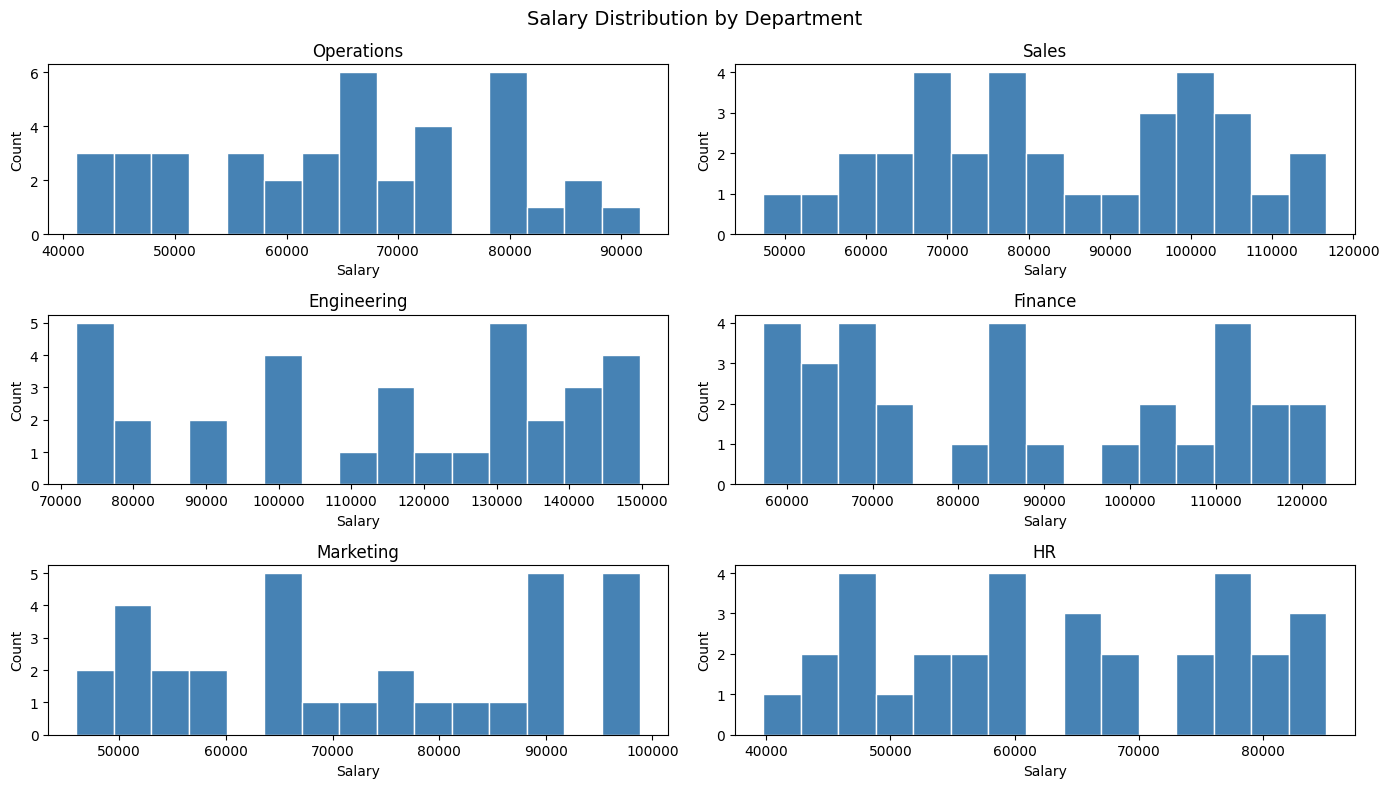

In [19]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
axes = axes.flatten()

for i, dept in enumerate(df['department'].unique()):
    subset = df[df['department'] == dept]['salary']
    axes[i].hist(subset, bins=15, color='steelblue', edgecolor='white')
    axes[i].set_title(dept)
    axes[i].set_xlabel("Salary")
    axes[i].set_ylabel("Count")

plt.suptitle("Salary Distribution by Department", fontsize=14)
plt.tight_layout()
plt.show()

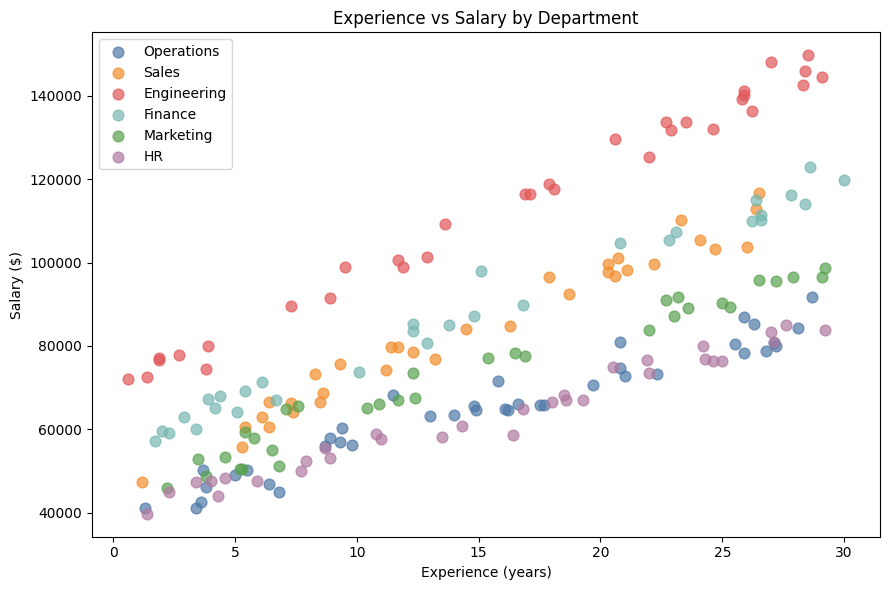

In [21]:
departments = df['department'].unique()
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#b07aa1']

plt.figure(figsize=(9, 6))
for dept, color in zip(departments, colors):
    sub = df[df['department'] == dept]
    plt.scatter(sub['experience_years'], sub['salary'],
                label=dept, color=color, alpha=0.7, s=60)

plt.xlabel("Experience (years)")
plt.ylabel("Salary ($)")
plt.title("Experience vs Salary by Department")
plt.legend()
plt.tight_layout()
plt.show()